# 0. Full Pipeline

This notebook combines local setup, training entry points, and analysis for the next-scale AttnRes experiments without Google Drive.


In [ ]:
!nvidia-smi 

Fri Mar 20 04:11:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [53]:
!git clone https://github.com/AtinChing/AttnResGPT-next-scale /content/AttnResGPT-next-scale


shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
Cloning into '/content/AttnResGPT-next-scale'...
fatal: Unable to read current working directory: No such file or directory


In [54]:
import os
os.chdir("/content")


In [1]:
%cd /content
!rm -rf /content/AttnResGPT-next-scale
!git clone https://github.com/AtinChing/AttnResGPT-next-scale.git /content/AttnResGPT-next-scale
%cd /content/AttnResGPT-next-scale
!pip install -q -r requirements.txt


/content
Cloning into '/content/AttnResGPT-next-scale'...
remote: Enumerating objects: 111, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 111 (delta 43), reused 108 (delta 40), pack-reused 0 (from 0)
Receiving objects: 100% (111/111), 57.13 KiB | 1.12 MiB/s, done.
Resolving deltas: 100% (43/43), done.
/content/AttnResGPT-next-scale
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 117.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 97.5 MB/s eta 0:00:00


In [22]:
import os
import subprocess
import sys
from pathlib import Path

def find_repo_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent, Path('/content/AttnResGPT-next-scale')]
    for candidate in candidates:
        if (candidate / 'src' / 'training' / 'train.py').exists() and (candidate / 'requirements.txt').exists():
            return candidate.resolve()
    raise FileNotFoundError(
        'Could not find AttnResGPT-next-scale. Open the notebook from the repo root or sync the repo to /content/AttnResGPT-next-scale.'
    )

REPO_DIR = find_repo_root()
os.chdir(REPO_DIR)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
print(f'Using repo at: {REPO_DIR}')


Using repo at: /content/AttnResGPT-next-scale


In [23]:
import torch

print('cuda_available =', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device_name =', torch.cuda.get_device_name(0))
    print('bf16_supported =', torch.cuda.is_bf16_supported())


cuda_available = True
device_name = Tesla T4
bf16_supported = True


## Stage 1: Required First-Run Experiment

This runs SMALL only, contexts 128 and 512, baseline plus AttnRes, 300 steps each.


In [64]:
!python experiments/scale_experiment.py --config configs/first_run.yaml --skip-existing


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: atin5551 (atin5551-uc-davis) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
]11;?]11;?wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ setting up run tinystories_small_baseline_ctx128_steps300_seed1337 (...
wandb: ⣷ setting up run tinystories_small_baseline_ctx128_steps300_seed1337 (...
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in outputs/runs/tinystories_small_baseline_ctx128_steps300_seed1337/wandb/run-20260320_052340-tinystories_small_baseline_ctx128_steps300_seed1337
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run tinystories_small_baseline_ctx128_steps300_seed1337
wandb: ⭐️ View project at https://wandb.ai/atin5551-uc-davis/attnres-next-scale
wandb: 🚀 View run at https://wandb.ai/atin5551-uc-davis/attnres-next-sca

In [25]:
import pandas as pd
summary_df = pd.read_csv('outputs/logs/run_summaries.csv')
consolidated_df = pd.read_csv('outputs/logs/consolidated_summary_table.csv')
paired_df = pd.read_csv('outputs/logs/paired_comparisons.csv')
display(consolidated_df.sort_values(['size', 'context', 'model']))
display(paired_df.sort_values(['size', 'context']))


,model,size,context,val_loss,perplexity,second_half_loss,mean_activation_norm_last_layer,mean_early_contribution,mean_late_contribution
0,attnres,small,128,4.275399,71.908844,4.252221,8.691619,0.517703,0.256639
2,baseline,small,128,4.372255,79.222099,4.350169,6.115869,NaN,NaN
1,attnres,small,512,4.129411,62.141296,4.119111,9.255941,0.527947,0.255026
3,baseline,small,512,4.181706,65.477463,4.172117,5.508213,NaN,NaN


,size,context,baseline_val_loss,attnres_val_loss,delta_val_loss,baseline_ppl,attnres_ppl,delta_ppl,baseline_params,attnres_params,parameter_delta_pct
0,small,128,4.372255,4.275399,0.096856,79.222099,71.908844,7.313255,29990400,30000384,0.033291
1,small,512,4.181706,4.129411,0.052295,65.477463,62.141296,3.336166,30137856,30147840,0.033128


In [29]:
import os
print("WANDB_API_KEY set:", bool(os.environ.get("WANDB_API_KEY")))
print("WANDB_MODE:", os.environ.get("WANDB_MODE", "<auto>"))


WANDB_API_KEY set: True
WANDB_MODE: <auto>


In [2]:
import os
import wandb

os.environ["WANDB_API_KEY"] = "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"
os.environ.pop("WANDB_MODE", None)  # let repo choose auto
wandb.login(key=os.environ["WANDB_API_KEY"], relogin=True)
print("logged in")


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: atin5551 (atin5551-uc-davis) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


logged in


In [3]:
import wandb
api = wandb.Api()

artifact = api.artifact("atin5551-uc-davis/attnres-next-scale/attnres-outputs-backup:latest")
artifact_dir = artifact.download(root="/content/wandb_artifacts")
print(artifact_dir)


wandb: Downloading large artifact 'attnres-outputs-backup:latest', 10249.24MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:01:49.9 (93.2MB/s)


/content/wandb_artifacts


In [4]:
!find /content/wandb_artifacts -name "*.tar.gz" -o -name "*.tgz"


/content/wandb_artifacts/attnres_outputs_backup.tar.gz


In [7]:
import os
import glob
import wandb

api = wandb.Api()
artifact = api.artifact("atin5551-uc-davis/attnres-next-scale/attnres-outputs-backup:latest")
artifact_dir = artifact.download(root="/content/wandb_artifacts")

print("artifact_dir =", artifact_dir)
print("top-level files =", os.listdir(artifact_dir))
print("tarballs =", glob.glob(f"{artifact_dir}/**/*.tar.gz", recursive=True))


wandb: Downloading large artifact 'attnres-outputs-backup:latest', 10249.24MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.2 (42201.3MB/s)


artifact_dir = /content/wandb_artifacts
top-level files = ['attnres_outputs_backup.tar.gz']
tarballs = ['/content/wandb_artifacts/attnres_outputs_backup.tar.gz']


In [9]:
!tar -xzf "$tar_path" -C /content/AttnResGPT-next-scale


In [10]:
from pathlib import Path
import json

root = Path("/content/AttnResGPT-next-scale")

print("run summaries:", len(list((root / "outputs/runs").glob("*/run_summary.json"))))
print("checkpoints:", len(list((root / "outputs/checkpoints").glob("*/step_*.pt"))))

for meta in sorted((root / "outputs/runs").glob("*/run_metadata.json")):
    data = json.loads(meta.read_text())
    print(meta.parent.name, "| status:", data.get("status"))


run summaries: 12
checkpoints: 24
tinystories_medium_attnres_ctx128_steps200_seed1337 | status: completed
tinystories_medium_attnres_ctx256_steps200_seed1337 | status: completed
tinystories_medium_attnres_ctx512_steps200_seed1337 | status: completed
tinystories_medium_baseline_ctx128_steps200_seed1337 | status: completed
tinystories_medium_baseline_ctx256_steps200_seed1337 | status: completed
tinystories_medium_baseline_ctx512_steps200_seed1337 | status: completed
tinystories_small_attnres_ctx128_steps300_seed1337 | status: completed
tinystories_small_attnres_ctx256_steps300_seed1337 | status: completed
tinystories_small_attnres_ctx512_steps300_seed1337 | status: completed
tinystories_small_baseline_ctx128_steps300_seed1337 | status: completed
tinystories_small_baseline_ctx256_steps300_seed1337 | status: completed
tinystories_small_baseline_ctx512_steps300_seed1337 | status: completed


In [ ]:
%cd /content/AttnResGPT-next-scale
!python experiments/scale_experiment.py --config configs/large.yaml --skip-existing
# maybe run this depending on output tho

/content/AttnResGPT-next-scale
config.json: 100% 665/665 [00:00<00:00, 3.38MB/s]
tokenizer_config.json: 100% 26.0/26.0 [00:00<00:00, 152kB/s]
vocab.json: 1.04MB [00:00, 19.6MB/s]
merges.txt: 456kB [00:00, 5.60MB/s]
tokenizer.json: 1.36MB [00:00, 10.4MB/s]
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: atin5551 (atin5551-uc-davis) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
]11;?]11;?wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ setting up run tinystories_large_baseline_ctx256_steps2000_seed42 (0...
wandb: ⣷ setting up run tinystories_large_baseline_ctx256_steps2000_seed42 (0...
wandb: ⣯ setting up run tinystories_large_baseline_ctx256_steps2000_seed42 (0...
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in outputs/runs/tinystories_large_baseline_ctx256_steps2000_seed42/wandb/run-202

In [ ]:
from pathlib import Path
import json

for meta_path in sorted(Path("/content/AttnResGPT-next-scale/outputs_wandb_smoke/runs").glob("*/run_metadata.json")):
    data = json.loads(meta_path.read_text())
    print(meta_path.parent.name)
    print("  status:", data.get("status"))
    print("  wandb_enabled:", data.get("wandb_enabled"))
    print("  wandb_mode:", data.get("wandb_mode"))
    print("  wandb_project:", data.get("wandb_project"))
    print("  wandb_run_name:", data.get("wandb_run_name"))
    print("  wandb_url:", data.get("wandb_url"))
    print("  wandb_error:", data.get("wandb_error"))


In [62]:
!python -m src.training.train \
  --config configs/first_run.yaml \
  --model baseline \
  --overrides training.max_steps=2 logging.output_root=outputs_wandb_smoke


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: atin5551 (atin5551-uc-davis) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
]11;?]11;?wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ setting up run tinystories_small_baseline_ctx128_steps2_seed1337 (0.3s)
wandb: ⣷ setting up run tinystories_small_baseline_ctx128_steps2_seed1337 (0.3s)
wandb: ⣯ setting up run tinystories_small_baseline_ctx128_steps2_seed1337 (0.3s)
wandb: ⣟ setting up run tinystories_small_baseline_ctx128_steps2_seed1337 (0.3s)
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in outputs_wandb_smoke/runs/tinystories_small_baseline_ctx128_steps2_seed1337/wandb/run-20260320_052253-tinystories_small_baseline_ctx128_steps2_seed1337
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run tinystories_small_baseline_ctx128_

## Optional Sweeps

Uncomment the sweep you want to run after the first-run path is stable.


In [65]:
!rm -f /content/AttnResGPT-next-scale/outputs/logs/tinystories_small_*
!rm -f /content/AttnResGPT-next-scale/outputs/logs/tinystories_medium_*
!rm -f /content/AttnResGPT-next-scale/outputs/logs/tinystories_large_*
!rm -rf /content/AttnResGPT-next-scale/outputs/runs/tinystories_small_*
!rm -rf /content/AttnResGPT-next-scale/outputs/runs/tinystories_medium_*
!rm -rf /content/AttnResGPT-next-scale/outputs/runs/tinystories_large_*
!rm -rf /content/AttnResGPT-next-scale/outputs/checkpoints/tinystories_small_*
!rm -rf /content/AttnResGPT-next-scale/outputs/checkpoints/tinystories_medium_*
!rm -rf /content/AttnResGPT-next-scale/outputs/checkpoints/tinystories_large_*



In [66]:
!python experiments/scale_experiment.py --config configs/small.yaml --skip-existing
!python experiments/scale_experiment.py --config configs/medium.yaml --skip-existing
!python experiments/scale_experiment.py --config configs/large.yaml --skip-existing


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: atin5551 (atin5551-uc-davis) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
]11;?]11;?wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ setting up run tinystories_small_baseline_ctx128_steps300_seed1337 (...
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in outputs/runs/tinystories_small_baseline_ctx128_steps300_seed1337/wandb/run-20260320_053823-tinystories_small_baseline_ctx128_steps300_seed1337
wandb: Run `wandb offline` to turn off syncing.
wandb: Resuming run tinystories_small_baseline_ctx128_steps300_seed1337
wandb: ⭐️ View project at https://wandb.ai/atin5551-uc-davis/attnres-next-scale
wandb: 🚀 View run at https://wandb.ai/atin5551-uc-davis/attnres-next-scale/runs/tinystories_small_baseline_ctx128_steps300_seed1337
wandb: WARNING The g

In [72]:
%cd /content/AttnResGPT-next-scale


/content/AttnResGPT-next-scale


In [73]:
!find outputs/checkpoints -name "step_*.pt" | sort | tail -20


outputs/checkpoints/tinystories_medium_attnres_ctx512_steps200_seed1337/step_0000100.pt
outputs/checkpoints/tinystories_medium_attnres_ctx512_steps200_seed1337/step_0000200.pt
outputs/checkpoints/tinystories_medium_baseline_ctx128_steps200_seed1337/step_0000100.pt
outputs/checkpoints/tinystories_medium_baseline_ctx128_steps200_seed1337/step_0000200.pt
outputs/checkpoints/tinystories_medium_baseline_ctx256_steps200_seed1337/step_0000100.pt
outputs/checkpoints/tinystories_medium_baseline_ctx256_steps200_seed1337/step_0000200.pt
outputs/checkpoints/tinystories_medium_baseline_ctx512_steps200_seed1337/step_0000100.pt
outputs/checkpoints/tinystories_medium_baseline_ctx512_steps200_seed1337/step_0000200.pt
outputs/checkpoints/tinystories_small_attnres_ctx128_steps300_seed1337/step_0000200.pt
outputs/checkpoints/tinystories_small_attnres_ctx128_steps300_seed1337/step_0000300.pt
outputs/checkpoints/tinystories_small_attnres_ctx256_steps300_seed1337/step_0000200.pt
outputs/checkpoints/tinystori

In [74]:
from pathlib import Path
import json

for meta in sorted(Path("outputs/runs").glob("*/run_metadata.json")):
    data = json.loads(meta.read_text())
    print(meta.parent.name)
    print("  status:", data.get("status"))
    print("  checkpoint_path:", data.get("checkpoint_path"))


tinystories_medium_attnres_ctx128_steps200_seed1337
  status: completed
  checkpoint_path: outputs/checkpoints/tinystories_medium_attnres_ctx128_steps200_seed1337/step_0000200.pt
tinystories_medium_attnres_ctx256_steps200_seed1337
  status: completed
  checkpoint_path: outputs/checkpoints/tinystories_medium_attnres_ctx256_steps200_seed1337/step_0000200.pt
tinystories_medium_attnres_ctx512_steps200_seed1337
  status: completed
  checkpoint_path: outputs/checkpoints/tinystories_medium_attnres_ctx512_steps200_seed1337/step_0000200.pt
tinystories_medium_baseline_ctx128_steps200_seed1337
  status: completed
  checkpoint_path: outputs/checkpoints/tinystories_medium_baseline_ctx128_steps200_seed1337/step_0000200.pt
tinystories_medium_baseline_ctx256_steps200_seed1337
  status: completed
  checkpoint_path: outputs/checkpoints/tinystories_medium_baseline_ctx256_steps200_seed1337/step_0000200.pt
tinystories_medium_baseline_ctx512_steps200_seed1337
  status: completed
  checkpoint_path: outputs/c

In [ ]:
!tar -czf /content/attnres_outputs_backup.tar.gz -C /content/AttnResGPT-next-scale outputs


In [77]:
from google.colab import files
files.download("/content/attnres_outputs_backup.tar.gz")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import wandb
artifact = wandb.Artifact("attnres-outputs-backup", type="backup")
artifact.add_file("/content/attnres_outputs_backup.tar.gz")
run = wandb.init(project="attnres-next-scale", job_type="backup")
run.log_artifact(artifact)
run.finish()


In [ ]:
!git rev-parse HEAD
!find outputs/runs -name run_summary.json | wc -l
!find outputs/checkpoints -name "step_*.pt" | wc -l


484c0b863a94e1b08611d841049eafd0cf612212
12
24


In [79]:
!du -sh /content/AttnResGPT-next-scale/outputs/* 2>/dev/null
!du -sh /content/AttnResGPT-next-scale/outputs/runs/* 2>/dev/null | sort -h | tail -20


11G	/content/AttnResGPT-next-scale/outputs/checkpoints
592K	/content/AttnResGPT-next-scale/outputs/logs
176K	/content/AttnResGPT-next-scale/outputs/plots
45M	/content/AttnResGPT-next-scale/outputs/runs
3.7M	/content/AttnResGPT-next-scale/outputs/runs/tinystories_medium_attnres_ctx128_steps200_seed1337
3.7M	/content/AttnResGPT-next-scale/outputs/runs/tinystories_medium_baseline_ctx128_steps200_seed1337
3.7M	/content/AttnResGPT-next-scale/outputs/runs/tinystories_medium_baseline_ctx256_steps200_seed1337
3.7M	/content/AttnResGPT-next-scale/outputs/runs/tinystories_medium_baseline_ctx512_steps200_seed1337
3.7M	/content/AttnResGPT-next-scale/outputs/runs/tinystories_small_attnres_ctx128_steps300_seed1337
3.7M	/content/AttnResGPT-next-scale/outputs/runs/tinystories_small_attnres_ctx512_steps300_seed1337
3.7M	/content/AttnResGPT-next-scale/outputs/runs/tinystories_small_baseline_ctx128_steps300_seed1337
3.7M	/content/AttnResGPT-next-scale/outputs/runs/tinystories_small_baseline_ctx256_steps30

## Analysis

This section reproduces the analysis notebook inside the same local workflow.


In [ ]:
import os
import subprocess
import sys
from pathlib import Path

def find_repo_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent, Path('/content/AttnResGPT-next-scale')]
    for candidate in candidates:
        if (candidate / 'src' / 'training' / 'train.py').exists() and (candidate / 'requirements.txt').exists():
            return candidate.resolve()
    raise FileNotFoundError(
        'Could not find AttnResGPT-next-scale. Open the notebook from the repo root or sync the repo to /content/AttnResGPT-next-scale.'
    )

REPO_DIR = find_repo_root()
os.chdir(REPO_DIR)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
print(f'Using repo at: {REPO_DIR}')
s

Using repo at: /content/AttnResGPT-next-scale


In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
summary_df = pd.read_csv('outputs/logs/run_summaries.csv')
consolidated_df = pd.read_csv('outputs/logs/consolidated_summary_table.csv')
paired_df = pd.read_csv('outputs/logs/paired_comparisons.csv')
display(consolidated_df.sort_values(['size', 'context', 'model']))
display(paired_df.sort_values(['size', 'context']))
if Path('outputs/summary_large.csv').exists():
    display(pd.read_csv('outputs/summary_large.csv').sort_values(['context', 'model']))
if Path('outputs/summary_large_comparison.csv').exists():
    display(pd.read_csv('outputs/summary_large_comparison.csv').sort_values(['context']))


,model,size,context,val_loss,perplexity,second_half_loss,mean_activation_norm_last_layer,mean_early_contribution,mean_late_contribution
0,attnres,medium,128,4.498343,89.868050,4.492580,14.238291,0.526896,0.274078
6,baseline,medium,128,4.751760,115.787949,4.739483,11.199033,NaN,NaN
1,attnres,medium,256,4.374828,79.426201,4.320407,17.540016,0.510285,0.284144
7,baseline,medium,256,4.578157,97.334793,4.527084,11.294371,NaN,NaN
2,attnres,medium,512,4.261648,70.926788,4.219261,14.603068,0.509212,0.287551
8,baseline,medium,512,4.432641,84.153374,4.374949,9.268698,NaN,NaN
3,attnres,small,128,4.275399,71.908844,4.252221,8.691619,0.517703,0.256639
9,baseline,small,128,4.372255,79.222099,4.350169,6.115869,NaN,NaN
4,attnres,small,256,4.215209,67.708282,4.182821,10.862446,0.496524,0.262095
10,baseline,small,256,4.297626,73.525040,4.269648,6.204403,NaN,NaN


,size,context,baseline_val_loss,attnres_val_loss,delta_val_loss,baseline_ppl,attnres_ppl,delta_ppl,baseline_params,attnres_params,parameter_delta_pct
0,medium,128,4.751760,4.498343,0.253418,115.787949,89.868050,25.919899,51008512,51025920,0.034128
1,medium,256,4.578157,4.374828,0.203328,97.334793,79.426201,17.908592,51074048,51091456,0.034084
2,medium,512,4.432641,4.261648,0.170993,84.153374,70.926788,13.226585,51205120,51222528,0.033997
3,small,128,4.372255,4.275399,0.096856,79.222099,71.908844,7.313255,29990400,30000384,0.033291
4,small,256,4.297626,4.215209,0.082417,73.525040,67.708282,5.816757,30039552,30049536,0.033236
5,small,512,4.181706,4.129411,0.052295,65.477463,62.141296,3.336166,30137856,30147840,0.033128


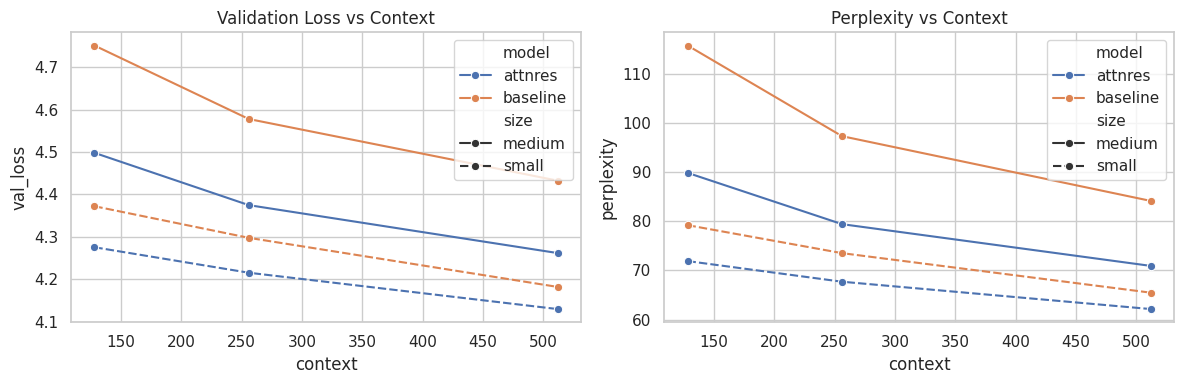

In [ ]:
plot_dir = Path('outputs/plots')
plot_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=summary_df, x='context', y='val_loss', hue='model', style='size', marker='o', ax=axes[0])
axes[0].set_title('Validation Loss vs Context')
sns.lineplot(data=summary_df, x='context', y='perplexity', hue='model', style='size', marker='o', ax=axes[1])
axes[1].set_title('Perplexity vs Context')
fig.tight_layout()
fig.savefig(plot_dir / 'loss_and_perplexity_vs_context.png', dpi=200)
plt.show()


In [ ]:
attnres_rows = summary_df[summary_df['model'] == 'attnres'][['run_name', 'context']].sort_values('context')
for _, row in attnres_rows.iterrows():
    summary_path = Path('outputs/runs') / row['run_name'] / 'run_summary.json'
    payload = json.loads(summary_path.read_text(encoding='utf-8'))
    heatmap = payload.get('depth_attention_rows', [])
    if not heatmap:
        continue
    plt.figure(figsize=(8, 4))
    sns.heatmap(heatmap, cmap='viridis')
    plt.title(f"AttnRes depth attention: {row['run_name']}")
    plt.xlabel('Source index')
    plt.ylabel('Depth-mixing row')
    plt.tight_layout()
    output_path = plot_dir / f"depth_heatmap_{row['run_name']}.png"
    plt.savefig(output_path, dpi=200)
    plt.show()


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (17,) + inhomogeneous part.

<Figure size 800x400 with 0 Axes>